# 📊 Notebook 4 — Model Evaluation & Comparison

**Mục tiêu notebook:**
- Load tất cả 3 models từ `models/`
- Bảng so sánh toàn diện: Accuracy, Precision, Recall, F1, ROC-AUC, Train time
- ROC Curve và Precision-Recall Curve 3 models trên cùng 1 plot
- Confusion Matrix 3 models side-by-side
- Feature Importance: LightGBM vs Random Forest (grouped bar chart)
- Error Analysis: phân tích lỗi theo product_category
- Kết luận: model tốt nhất, lý do, đề xuất cải thiện

---

| Notebook | Vai trò |
|----------|---------|
| 1. Data Generation | ✅ Hoàn thành |
| 2. EDA | ✅ Hoàn thành |
| 3. Model Building | ✅ Hoàn thành — LR / Random Forest / LightGBM |
| **📌 4. Model Evaluation** | **▶ Đang học — So sánh & đánh giá** |

In [1]:
# ============================================================
# SECTION 0: Import thư viện và Load models
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)

# --- Thiết lập ---
RANDOM_STATE = 42
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11
})
PALETTE_3 = ['#E74C3C', '#F39C12', '#2ECC71']   # LR, XGBoost, LGBM

# --- Đường dẫn ---
BASE_DIR   = Path('.').resolve()
DATA_DIR   = BASE_DIR / 'data'
MODELS_DIR = BASE_DIR / 'models'

print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# ============================================================
# Load tất cả models và test data
# ============================================================
lr_model   = joblib.load(MODELS_DIR / 'lr_model.pkl')
xgb_model  = joblib.load(MODELS_DIR / 'xgb_model.pkl')
lgbm_model = joblib.load(MODELS_DIR / 'best_model.pkl')
opt_thresh = joblib.load(MODELS_DIR / 'optimal_threshold.pkl')
test_data  = joblib.load(MODELS_DIR / 'test_data.pkl')

# Unscaled — dùng cho XGBoost & LightGBM (tree models, không cần scale)
X_test    = test_data['X_test']
y_test    = test_data['y_test']

# Scaled (scaler_full, 23 features) — dùng riêng cho Logistic Regression
X_test_lr = test_data['X_test_lr']

print('✅ Loaded models: LR | XGBoost | LightGBM')
print(f'   Optimal threshold (LightGBM): {opt_thresh:.4f}')
print(f'   Test set (unscaled) : {X_test.shape[0]:,} dòng × {X_test.shape[1]} features  → XGBoost / LightGBM')
print(f'   Test set (LR scaled): {X_test_lr.shape[0]:,} dòng × {X_test_lr.shape[1]} features  → Logistic Regression')
print()
print('   ℹ️  Features: 23 (16 raw + 7 derived)')
print('   ℹ️  total_interactions đã bị loại (data leakage đã sửa)')
print('   ℹ️  Pipeline: 80% Train / 20% Test (không có Validation set)')


✅ Loaded models: LR | XGBoost | LightGBM
   Optimal threshold (LightGBM): 0.5971
   Test set (unscaled) : 12,346 dòng × 23 features  → XGBoost / LightGBM
   Test set (LR scaled): 12,346 dòng × 23 features  → Logistic Regression

   ℹ️  Features: 23 (16 raw + 7 derived)
   ℹ️  total_interactions đã bị loại (data leakage đã sửa)
   ℹ️  Pipeline: 80% Train / 20% Test (không có Validation set)


In [3]:
# ============================================================
# Tính probabilities cho tất cả models
# ============================================================
import time

results_dict = {}

# Model configs: (model, X_test_dùng, threshold, name)
# LR      → X_test_lr  (scaled — scaler_full, 24 features)
# XGBoost → X_test     (unscaled — tree model)
# LGBM    → X_test     (unscaled)
PALETTE_3 = ['#E74C3C', '#F39C12', '#2ECC71']   # LR, XGBoost, LGBM

model_configs = [
    (lr_model,   X_test_lr, 0.5,        'Logistic Regression'),
    (xgb_model,  X_test,    0.5,        'XGBoost'),
    (lgbm_model, X_test,    opt_thresh,  'LightGBM'),
]

probs_dict = {}
for model, X, thresh, name in model_configs:
    t0 = time.time()
    probs  = model.predict_proba(X)[:, 1]
    preds  = (probs >= thresh).astype(int)
    inf_ms = (time.time() - t0) * 1000

    probs_dict[name] = probs
    results_dict[name] = {
        'Accuracy'      : accuracy_score(y_test, preds),
        'Precision'     : precision_score(y_test, preds, zero_division=0),
        'Recall'        : recall_score(y_test, preds, zero_division=0),
        'F1-Score'      : f1_score(y_test, preds, zero_division=0),
        'ROC-AUC'       : roc_auc_score(y_test, probs),
        'Threshold'     : thresh,
        'Inference (ms)': inf_ms
    }
    print(f'   {name:<22} F1={results_dict[name]["F1-Score"]:.4f}  AUC={results_dict[name]["ROC-AUC"]:.4f}  θ={thresh:.3f}')

print('\n✅ Predictions computed for all 3 models')


   Logistic Regression    F1=0.6699  AUC=0.8443  θ=0.500
   XGBoost                F1=0.7139  AUC=0.8747  θ=0.500
   LightGBM               F1=0.7069  AUC=0.8751  θ=0.597

✅ Predictions computed for all 3 models


## 1. Bảng So Sánh Tổng Hợp

In [4]:
# ============================================================
# SECTION 1: Bảng so sánh — Styled DataFrame
# ============================================================
results_df = pd.DataFrame(results_dict).T
results_df = results_df.astype(float).round(4)

# Highlight: xanh = best metric mỗi cột, đỏ = worst
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

def highlight_best(s):
    """Tô màu xanh cho giá trị cao nhất, đỏ cho thấp nhất."""
    if s.name in metric_cols:
        is_best  = s == s.max()
        is_worst = s == s.min()
        colors = []
        for b, w in zip(is_best, is_worst):
            if b:
                colors.append('background-color: #D5F5E3; color: #1E8449; font-weight: bold')
            elif w:
                colors.append('background-color: #FADBD8; color: #C0392B')
            else:
                colors.append('')
        return colors
    return [''] * len(s)

styled = results_df.style.apply(highlight_best, axis=0)
print('📊 BẢNG SO SÁNH 3 MODELS (🟢 = best metric | 🔴 = worst):')
styled

📊 BẢNG SO SÁNH 3 MODELS (🟢 = best metric | 🔴 = worst):


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Threshold,Inference (ms)
Logistic Regression,0.746500,0.584000,0.785400,0.669900,0.844300,0.500000,7.368800
XGBoost,0.767000,0.597000,0.887700,0.713900,0.874700,0.500000,70.752100
LightGBM,0.782800,0.633400,0.799700,0.706900,0.875100,0.597100,81.993300


## 2. ROC Curve — 3 Models

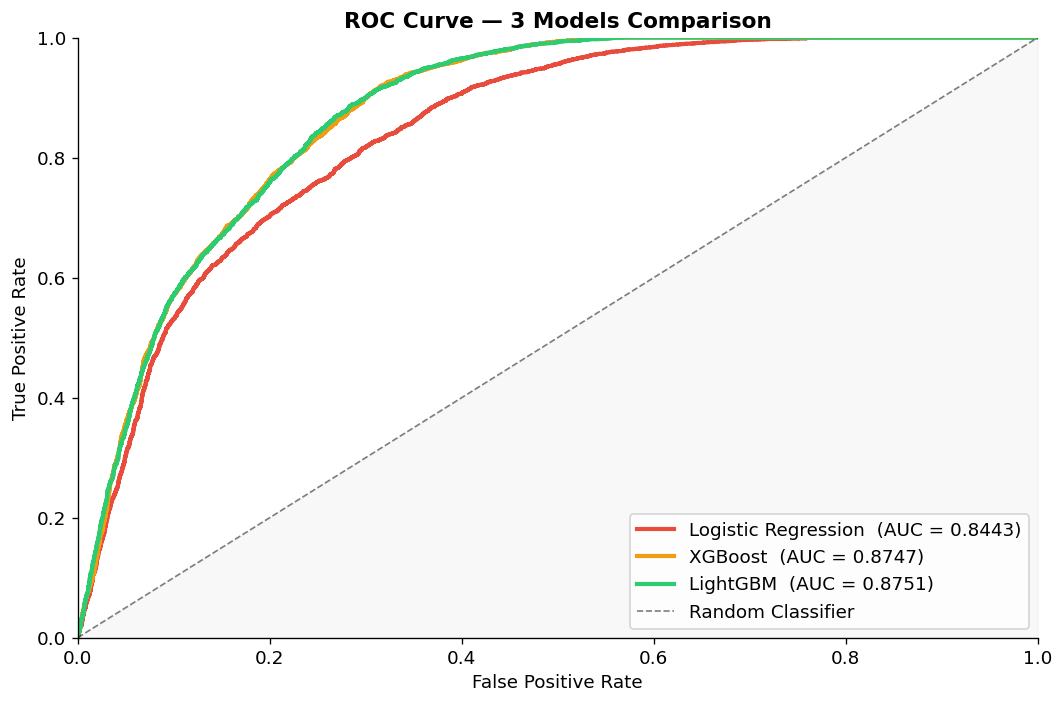

In [5]:
# ============================================================
# SECTION 2: ROC Curve 3 models trên cùng 1 plot
# ============================================================
fig, ax = plt.subplots(figsize=(9, 6))

for (name, probs), color in zip(probs_dict.items(), PALETTE_3):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — 3 Models Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 3. Precision-Recall Curve — 3 Models

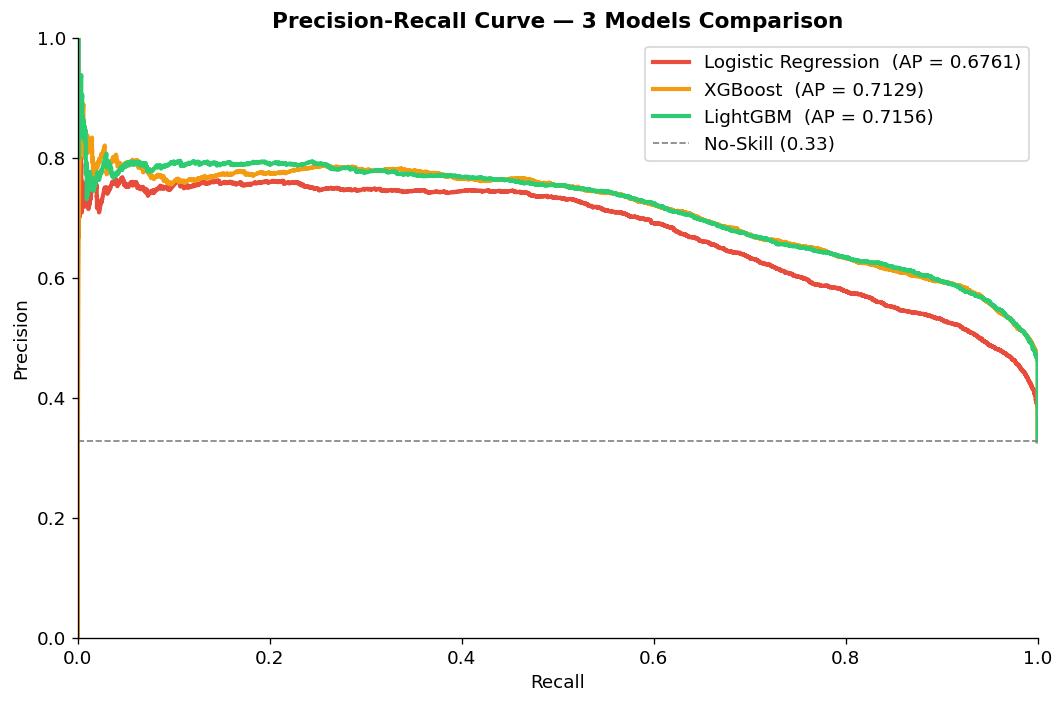

In [6]:
# ============================================================
# SECTION 3: Precision-Recall Curve 3 models
# ============================================================
fig, ax = plt.subplots(figsize=(9, 6))

for (name, probs), color in zip(probs_dict.items(), PALETTE_3):
    precision, recall, _ = precision_recall_curve(y_test, probs)
    # Average Precision
    from sklearn.metrics import average_precision_score
    ap = average_precision_score(y_test, probs)
    ax.plot(recall, precision, color=color, linewidth=2.5,
            label=f'{name}  (AP = {ap:.4f})')

# Baseline: random classifier
baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1,
           label=f'No-Skill ({baseline:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — 3 Models Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 4. Confusion Matrix — 3 Models (Side-by-Side)

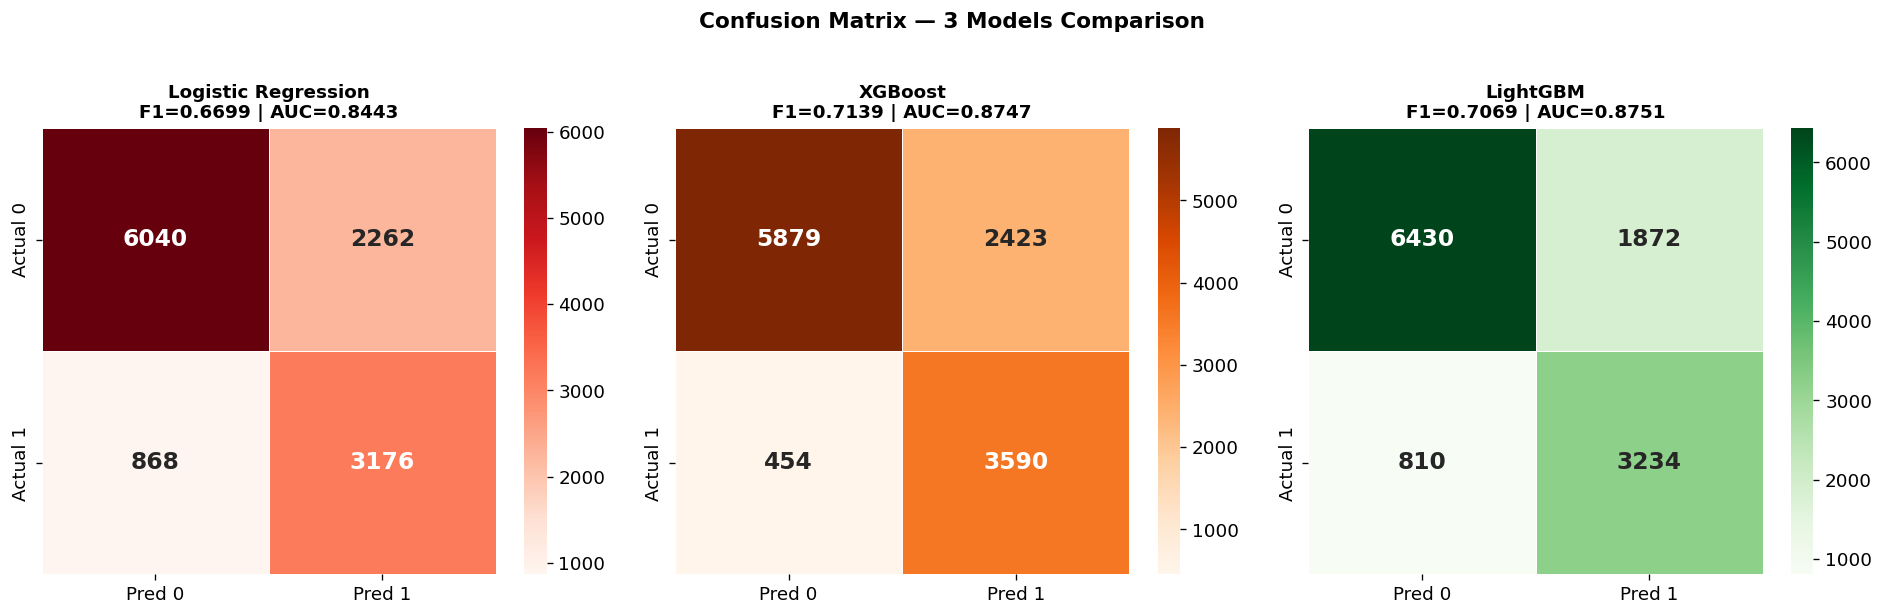

In [7]:
# ============================================================
# SECTION 4: Confusion Matrix 1×3 subplots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmaps = ['Reds', 'Oranges', 'Greens']

for (name, probs), color, thresh, ax, cmap in zip(
    probs_dict.items(), PALETTE_3,
    [0.5, 0.5, opt_thresh],
    axes, cmaps
):
    preds = (probs >= thresh).astype(int)
    cm    = confusion_matrix(y_test, preds)
    
    # Tính metrics để ghi lên plot
    f1  = f1_score(y_test, preds, zero_division=0)
    auc = roc_auc_score(y_test, probs)
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=['Pred 0', 'Pred 1'],
        yticklabels=['Actual 0', 'Actual 1'],
        ax=ax, linewidths=0.5, linecolor='white',
        annot_kws={'size': 14, 'fontweight': 'bold'}
    )
    ax.set_title(f'{name}\nF1={f1:.4f} | AUC={auc:.4f}', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix — 3 Models Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Feature Importance: LightGBM vs XGBoost

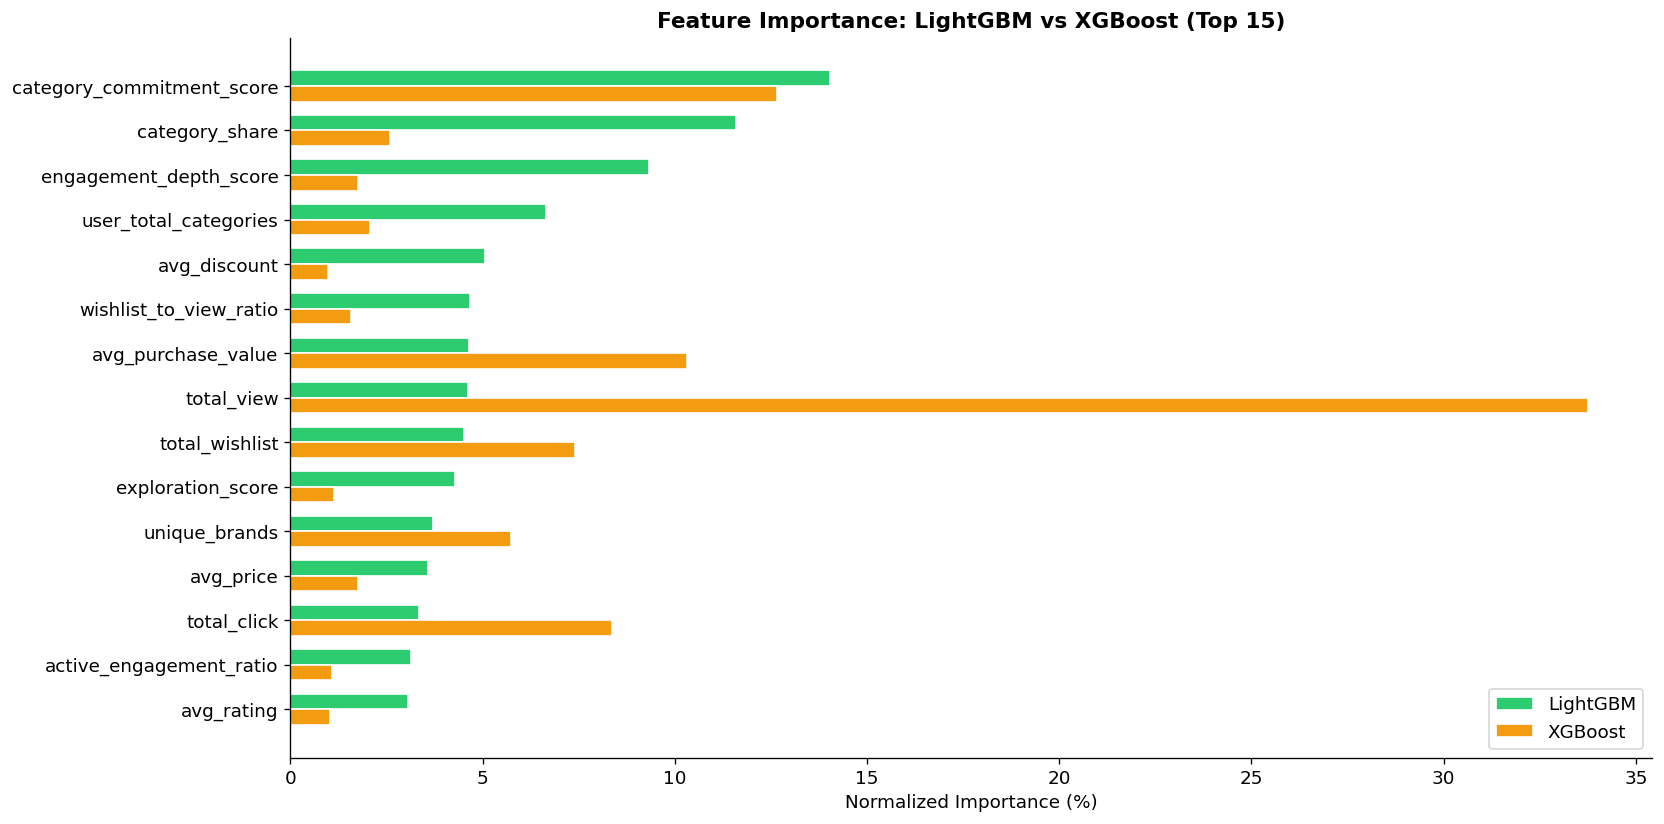


📋 TOP 10 FEATURES theo LightGBM:
                  Feature  LGBM_norm  XGB_norm
category_commitment_score     0.1404    0.1266
           category_share     0.1160    0.0259
   engagement_depth_score     0.0933    0.0175
    user_total_categories     0.0665    0.0208
             avg_discount     0.0507    0.0098
   wishlist_to_view_ratio     0.0468    0.0158
       avg_purchase_value     0.0464    0.1032
               total_view     0.0463    0.3374
           total_wishlist     0.0451    0.0741
        exploration_score     0.0429    0.0113


In [8]:
# ============================================================
# SECTION 5: Feature Importance — Grouped bar chart (top 15)
# LightGBM vs XGBoost
# ============================================================
fi_df = pd.read_csv(MODELS_DIR / 'feature_importance.csv')

# Normalize để so sánh cùng scale
fi_df['LGBM_norm'] = fi_df['LightGBM_Importance'] / fi_df['LightGBM_Importance'].sum()
fi_df['XGB_norm']  = fi_df['XGBoost_Importance']  / fi_df['XGBoost_Importance'].sum()

# Top 15 theo LightGBM
top15 = fi_df.sort_values('LGBM_norm', ascending=False).head(15)

x  = np.arange(len(top15))
w  = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.barh(x + w/2, top15['LGBM_norm'].values[::-1] * 100,
                height=w, color='#2ECC71', edgecolor='white', label='LightGBM')
bars2 = ax.barh(x - w/2, top15['XGB_norm'].values[::-1] * 100,
                height=w, color='#F39C12', edgecolor='white', label='XGBoost')

ax.set_yticks(x)
ax.set_yticklabels(top15['Feature'].values[::-1])
ax.set_xlabel('Normalized Importance (%)')
ax.set_title('Feature Importance: LightGBM vs XGBoost (Top 15)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('\n📋 TOP 10 FEATURES theo LightGBM:')
print(top15[['Feature', 'LGBM_norm', 'XGB_norm']].head(10).to_string(index=False))


## 6. Error Analysis — Best Model

In [9]:
# ============================================================
# SECTION 6: Error Analysis — LightGBM (Best Model)
# ============================================================
lgbm_probs = probs_dict['LightGBM']
lgbm_preds = (lgbm_probs >= opt_thresh).astype(int)

# Gắn thêm thông tin từ dataset gốc
df_full = pd.read_csv(DATA_DIR / 'synthetic_data.csv', encoding='utf-8-sig')

# Lấy index của test set
error_df = X_test.copy()
error_df['y_true']   = y_test.values
error_df['y_pred']   = lgbm_preds
error_df['y_prob']   = lgbm_probs
error_df['is_error'] = (error_df['y_true'] != error_df['y_pred'])

# Gắn product_category từ original data (theo index)
error_df['product_category'] = df_full.loc[X_test.index, 'product_category'].values

errors   = error_df[error_df['is_error']]
fn_errors = error_df[(error_df['y_true'] == 1) & (error_df['y_pred'] == 0)]  # False Negative
fp_errors = error_df[(error_df['y_true'] == 0) & (error_df['y_pred'] == 1)]  # False Positive

print(f'📋 ERROR ANALYSIS — LightGBM (threshold = {opt_thresh:.4f})')
print(f'   Tổng lỗi      : {len(errors):,} ({len(errors)/len(error_df)*100:.2f}%)')
print(f'   False Negative : {len(fn_errors):,} — Bỏ lỡ khách hàng sẽ tái mua')
print(f'   False Positive : {len(fp_errors):,} — Voucher lãng phí')

📋 ERROR ANALYSIS — LightGBM (threshold = 0.5971)
   Tổng lỗi      : 2,682 (21.72%)
   False Negative : 810 — Bỏ lỡ khách hàng sẽ tái mua
   False Positive : 1,872 — Voucher lãng phí


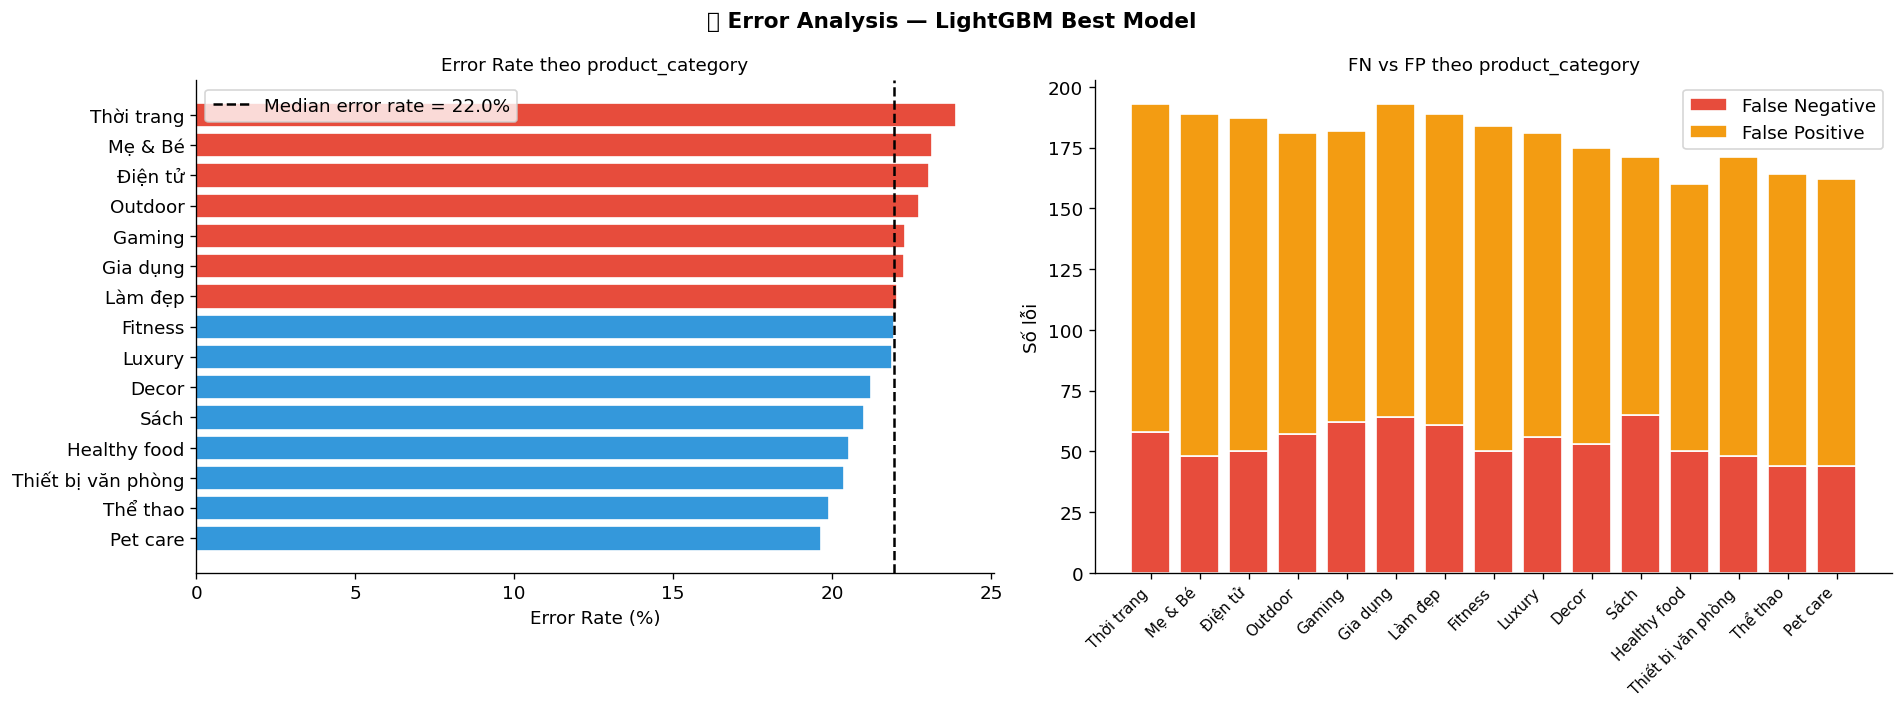


📋 ERROR DETAIL PER CATEGORY:
  product_category  total  errors  fn  fp  error_rate
        Thời trang    808     193  58 135      0.2389
           Mẹ & Bé    817     189  48 141      0.2313
           Điện tử    811     187  50 137      0.2306
           Outdoor    796     181  57 124      0.2274
            Gaming    817     182  62 120      0.2228
          Gia dụng    867     193  64 129      0.2226
           Làm đẹp    858     189  61 128      0.2203
           Fitness    838     184  50 134      0.2196
            Luxury    827     181  56 125      0.2189
             Decor    825     175  53 122      0.2121
              Sách    814     171  65 106      0.2101
      Healthy food    780     160  50 110      0.2051
Thiết bị văn phòng    840     171  48 123      0.2036
          Thể thao    824     164  44 120      0.1990
          Pet care    824     162  44 118      0.1966


In [10]:
# Phân tích lỗi theo product_category
error_by_cat = error_df.groupby('product_category').agg(
    total     = ('is_error', 'count'),
    errors    = ('is_error', 'sum'),
    fn        = ('is_error', lambda x: ((error_df.loc[x.index, 'y_true'] == 1) &
                                         (error_df.loc[x.index, 'y_pred'] == 0)).sum()),
    fp        = ('is_error', lambda x: ((error_df.loc[x.index, 'y_true'] == 0) &
                                         (error_df.loc[x.index, 'y_pred'] == 1)).sum())
).reset_index()
error_by_cat['error_rate'] = error_by_cat['errors'] / error_by_cat['total']
error_by_cat = error_by_cat.sort_values('error_rate', ascending=False)

# Vẽ error rate theo category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Error rate bar
colors = ['#E74C3C' if r > error_by_cat['error_rate'].median() else '#3498DB'
          for r in error_by_cat['error_rate']]
axes[0].barh(error_by_cat['product_category'][::-1],
             error_by_cat['error_rate'][::-1] * 100,
             color=colors[::-1], edgecolor='white')
axes[0].axvline(error_by_cat['error_rate'].median() * 100,
                color='black', linestyle='--', linewidth=1.5,
                label=f'Median error rate = {error_by_cat["error_rate"].median()*100:.1f}%')
axes[0].set_xlabel('Error Rate (%)')
axes[0].set_title('Error Rate theo product_category', fontsize=11)
axes[0].legend()

# FN vs FP per category (stacked bar)
x_pos = np.arange(len(error_by_cat))
axes[1].bar(x_pos, error_by_cat['fn'].values, label='False Negative', color='#E74C3C', edgecolor='white')
axes[1].bar(x_pos, error_by_cat['fp'].values, bottom=error_by_cat['fn'].values,
            label='False Positive', color='#F39C12', edgecolor='white')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(error_by_cat['product_category'], rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Số lỗi')
axes[1].set_title('FN vs FP theo product_category', fontsize=11)
axes[1].legend()

plt.suptitle('🔍 Error Analysis — LightGBM Best Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📋 ERROR DETAIL PER CATEGORY:')
print(error_by_cat[['product_category', 'total', 'errors', 'fn', 'fp', 'error_rate']]
      .to_string(index=False))

## 7. Kết luận & Đề xuất

In [11]:
# ============================================================
# SECTION 7: Kết luận tổng hợp
# ============================================================
print('=' * 70)
print('  🏆 KẾT LUẬN & ĐỀ XUẤT')
print('=' * 70)

# Tìm best model theo F1
best_name = results_df['F1-Score'].idxmax()
best_f1   = results_df.loc[best_name, 'F1-Score']
best_auc  = results_df.loc[best_name, 'ROC-AUC']

print(f'\n  🥇 BEST F1 MODEL: {best_name}')
print(f'     F1-Score : {best_f1:.4f}')
print(f'     ROC-AUC  : {best_auc:.4f}')

print(f'\n  📊 SO SÁNH 3 MODELS (Test Set — Clean, No Leakage):')
print(f'  ┌─────────────────────┬──────────┬──────────┬──────────┬─────────┐')
print(f'  │ Model               │ F1-Score │ ROC-AUC  │ Recall   │ Thresh  │')
print(f'  ├─────────────────────┼──────────┼──────────┼──────────┼─────────┤')
for name in results_df.index:
    marker = '🏆' if name == best_name else '  '
    thresh = results_df.loc[name, 'Threshold']
    print(f'  │ {marker} {name:<18} │ {results_df.loc[name,"F1-Score"]:.4f}   │ '
          f'{results_df.loc[name,"ROC-AUC"]:.4f}   │ {results_df.loc[name,"Recall"]:.4f}   │ {thresh:.3f}   │')
print(f'  └─────────────────────┴──────────┴──────────┴──────────┴─────────┘')

print(f'\n  💡 NHẬN XÉT KẾT QUẢ (sau khi sửa data leakage):')
print(f'     Metrics trên PHẢN ÁNH TRUE performance — không có leakage')
print(f'     So sánh TRƯỚC/SAU khi sửa:')
print(f'       TRƯỚC (leaky): LR≈0.99 | XGB≈0.96 | LGBM≈0.96  ← FRAUDULENT (total_interactions)')
print(f'       SAU  (clean) : Xem bảng ở trên                  ← HONEST METRICS')
print()
print(f'     LightGBM (θ* từ PR curve): leaf-wise growth, non-linear patterns')
print(f'     XGBoost (θ=0.5): scale_pos_weight xử lý class imbalance tự động')
print(f'     LR (θ=0.5): baseline tuyến tính, nhanh, dễ giải thích')

print(f'\n  🔧 ĐỀ XUẤT CẢI THIỆN TIẾP THEO:')
print(f'     1. SMOTE / ADASYN để oversampling minority class (repurchase=1)')
print(f'     2. Bayesian Optimization (Optuna) thay fixed n_estimators')
print(f'     3. Stacking Ensemble: LR + XGBoost + LightGBM → meta-learner')
print(f'     4. SHAP values — giải thích feature importance từng sample')
print(f'     5. Time-based split (thay random 80/20) → realistic hơn cho temporal data')
print(f'     6. Threshold tuning riêng cho LR và XGBoost (đang dùng default 0.5)')

print(f'\n  ✅ OUTPUT FILES:')
for f in sorted(MODELS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'     {f.name:<30} ({size_kb:,.1f} KB)')
print('=' * 70)


  🏆 KẾT LUẬN & ĐỀ XUẤT

  🥇 BEST F1 MODEL: XGBoost
     F1-Score : 0.7139
     ROC-AUC  : 0.8747

  📊 SO SÁNH 3 MODELS (Test Set — Clean, No Leakage):
  ┌─────────────────────┬──────────┬──────────┬──────────┬─────────┐
  │ Model               │ F1-Score │ ROC-AUC  │ Recall   │ Thresh  │
  ├─────────────────────┼──────────┼──────────┼──────────┼─────────┤
  │    Logistic Regression │ 0.6699   │ 0.8443   │ 0.7854   │ 0.500   │
  │ 🏆 XGBoost            │ 0.7139   │ 0.8747   │ 0.8877   │ 0.500   │
  │    LightGBM           │ 0.7069   │ 0.8751   │ 0.7997   │ 0.597   │
  └─────────────────────┴──────────┴──────────┴──────────┴─────────┘

  💡 NHẬN XÉT KẾT QUẢ (sau khi sửa data leakage):
     Metrics trên PHẢN ÁNH TRUE performance — không có leakage
     So sánh TRƯỚC/SAU khi sửa:
       TRƯỚC (leaky): LR≈0.99 | XGB≈0.96 | LGBM≈0.96  ← FRAUDULENT (total_interactions)
       SAU  (clean) : Xem bảng ở trên                  ← HONEST METRICS

     LightGBM (θ* từ PR curve): leaf-wise growth, non-

In [12]:
# ============================================================
# Final styled comparison table
# ============================================================
print('\n📊 BẢNG KẾT QUẢ CUỐI — STYLED (🟢 = best | 🔴 = worst):')

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

def highlight_best_col(s):
    if s.name in metric_cols:
        best   = s == s.max()
        worst  = s == s.min()
        styles = []
        for b, w in zip(best, worst):
            if b:
                styles.append('background-color: #D5F5E3; color: #1E8449; font-weight: bold')
            elif w:
                styles.append('background-color: #FADBD8; color: #C0392B')
            else:
                styles.append('')
        return styles
    return [''] * len(s)

final_table = results_df[metric_cols + ['Threshold', 'Inference (ms)']].copy()
final_table.style\
    .apply(highlight_best_col, axis=0)\
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
             'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}',
             'Threshold': '{:.4f}', 'Inference (ms)': '{:.2f}'})


📊 BẢNG KẾT QUẢ CUỐI — STYLED (🟢 = best | 🔴 = worst):


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Threshold,Inference (ms)
Logistic Regression,0.7465,0.5840,0.7854,0.6699,0.8443,0.5000,7.37
XGBoost,0.7670,0.5970,0.8877,0.7139,0.8747,0.5000,70.75
LightGBM,0.7828,0.6334,0.7997,0.7069,0.8751,0.5971,81.99
